# 查看语料

In [1]:
words = open("names.txt", 'r').read().splitlines()
len(words)

32033

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
min(len(w) for w in words), max(len(w) for w in words), sum(len(w) for w in words)/len(words)

(2, 15, 6.122217712983486)

# Bigram

对于字符级别的语言模型来说, `Bigram`意味着每次只处理两个字符（而不是word级别是两个分词）
+ 即每次只给定一个字符，然后预测下一个字符 → 总是根据前一个(previous)字符预测下一个(next)字符
+ 相当于只对局部结构建模（也可以理解为: 建模的窗口只有2个字符）, 会导致忽略掉很多其他信息

In [4]:
for w in words[:3]:
    chs = ['<S>'] + list(w) + ['<E>'] 
    # 添加首尾
    for ch1, ch2 in zip(chs, chs[1:]):
        # 这里的遍历, 只要有一个列表到头了,整个遍历过程就停止了
        print(ch1,ch2)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>
<S> a
a v
v a
a <E>


构建一种字典结构，来统计每个bigram对出现的次数

In [5]:
b = {}
for w in words[:3]:
    chs = ['<S>'] + list(w) + ['<E>'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) + 1
        # print(ch1,ch2)
b

{('<S>', 'e'): 1,
 ('e', 'm'): 1,
 ('m', 'm'): 1,
 ('m', 'a'): 1,
 ('a', '<E>'): 3,
 ('<S>', 'o'): 1,
 ('o', 'l'): 1,
 ('l', 'i'): 1,
 ('i', 'v'): 1,
 ('v', 'i'): 1,
 ('i', 'a'): 1,
 ('<S>', 'a'): 1,
 ('a', 'v'): 1,
 ('v', 'a'): 1}

In [6]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [7]:
sorted_b = sorted(b.items(), key = lambda kv:kv[1])  # 按照值排序, 默认升序
sorted_b[0], sorted_b[-1]

((('q', 'r'), 1), (('n', '<E>'), 6763))

将这些bigram的出现次数放在二维数组中会更方便，
+ 比如：用行(row)表示bigram的第一个字符，用列(column)表示bigram的第二个字符
+ 这里也很好操作，对于字符级来说(这个语料只涉及26个字母 + 2个起始标志字符)，因此也就是一个 28行，28列的矩阵，直接每个字符映射一个整数，作为行号/列号即可
+ 计算也可以发现，上面只有627种组合，小于 28*28的组合，即：有些组合是不存在的，直接统计次数设置为0即可

只是因为这个语料比较简单，如果是更常规的英文自然语料，至少得是 ASCII 127个字符，那么矩阵就变成了 129*129了

如果是纯中文，就得变成6800左右的一个方阵了

In [8]:
len(b), (26+2)*(26+2)

(627, 784)

In [9]:
import torch
a= torch.zeros([3,5])
print(a, a.dtype)
# torch创建tensor的时候 默认是单精度浮点数，这里需要表示次数，因此，需要改成 torch.int32
a= torch.zeros([3,5], dtype=torch.int32)
print(a, a.dtype)

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]) torch.float32
tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32) torch.int32


In [10]:
for i,num in enumerate(['a', 'b', 'c']):
    print(i, num)

0 a
1 b
2 c


## 带有冗余的辞典

In [11]:
# 为了能够把字符/单词表示成整数， 这里需要构建 字符到整数的映射字典，以及整数到字符的映射字典
chars = sorted(list(set(''.join(words))))
print(chars[:3],len(chars))

# string/character to index
stoi = {s:i for i,s in enumerate(chars)}
stoi['<S>'] = 26
stoi['<E>'] = 27

itos = {i:s for s,i in stoi.items()}
# itos = {i:s for i,s in enumerate(chars)}
# itos[26] = '<S>'
# itos[27] = '<E>'
print(stoi["a"])
print(itos[0])

['a', 'b', 'c'] 26
0
a


In [12]:
N = torch.zeros([28,28], dtype=torch.int32)
for w in words:
    chs = ['<S>'] + list(w) + ['<E>'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        row = stoi[ch1]
        col = stoi[ch2]
        N[row,col]+=1

上面在统计 字典b的 次数的时候，有 ： `((('q', 'r'), 1), (('n', '<E>'), 6763))`， 这里验证下

In [13]:
row = stoi['n']
col = stoi['<E>']
N[row,col]

tensor(6763, dtype=torch.int32)

(-0.5, 27.5, 27.5, -0.5)

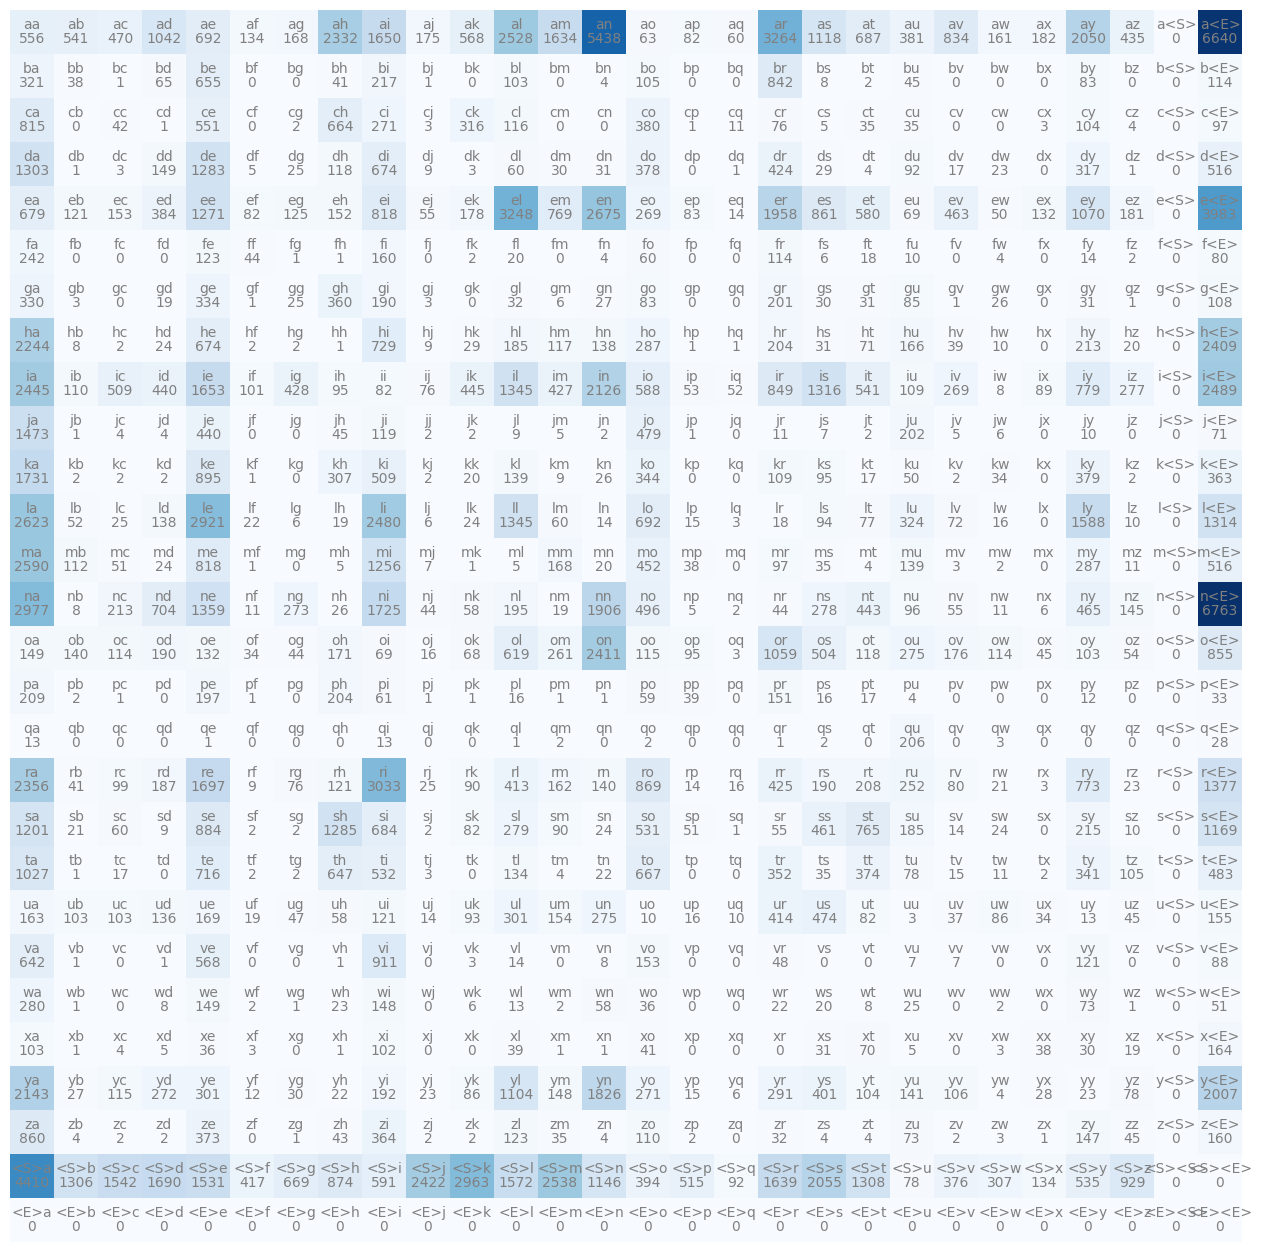

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline
# plt.imshow(N)  # 这样直接显示会很丑

plt.figure(figsize=(16,16))
plt.imshow(N, cmap = 'Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i]+itos[j]
        plt.text(j, i, chstr, ha = 'center', va = 'bottom', color = 'gray')
        plt.text(j, i, N[i,j].item(), ha = 'center', va = 'top', color = 'gray')
        # 如果是 plt.text(i,j,xxx)
        # 则第一行显示的是 aa,ba,ca,da
        #  第一列显示的是  aa,ab,ac,ad
        # 这里写成 j,i的原因是 j表示x轴，同时j是内循环，i表示y轴，i是外循环
        # 所以先i，第x行， 然后所有的j，第x列
plt.axis('off')

# 这里可以看到， plt.text(x: 'float',y: 'float'） 所以这里用j作为横坐标，i作为纵坐标，显示的是 N[i,j]和chstr 
# 不用特别在意matplotlib行列和 numpy行列相反这个问题
# 同理 在这里可以看到 n<E> 是6763 <E>在n后面的情况是出现了 6763次

从上图中可以看出：
+ 对于最后一行，`<E>`永远不会作为第一个字符出现
+ 对于导数第二列，`<S>`永远不会作为第二个字符出现
+ 因此，出现了一个整行和一个整列的0值
+ 同时倒数第二行，`<S>`开头的这行，出现了 `<S><E>`次数为0，也不会出现空字符的情况
+ 因此这些值是没有必要存储的，永远不会出现这种字符组合的情况

以前用pandas绘图的：[动手学深度学习V2.0(Pytorch)——23. LeNet（mnist）->2.1 灰度图显示mnist数字](https://stitch.blog.csdn.net/article/details/121845440)

In [15]:
import pandas as pd
df = pd.DataFrame(N)
df.columns = df.columns.map(itos)
df.index = df.index.map(itos)
df.style.set_properties(**{'font-size':'4pt'}).background_gradient('Greys')

,a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,x,y,z,,
a,556,541,470,1042,692,134,168,2332,1650,175,568,2528,1634,5438,63,82,60,3264,1118,687,381,834,161,182,2050,435,0,6640
b,321,38,1,65,655,0,0,41,217,1,0,103,0,4,105,0,0,842,8,2,45,0,0,0,83,0,0,114
c,815,0,42,1,551,0,2,664,271,3,316,116,0,0,380,1,11,76,5,35,35,0,0,3,104,4,0,97
d,1303,1,3,149,1283,5,25,118,674,9,3,60,30,31,378,0,1,424,29,4,92,17,23,0,317,1,0,516
e,679,121,153,384,1271,82,125,152,818,55,178,3248,769,2675,269,83,14,1958,861,580,69,463,50,132,1070,181,0,3983
f,242,0,0,0,123,44,1,1,160,0,2,20,0,4,60,0,0,114,6,18,10,0,4,0,14,2,0,80
g,330,3,0,19,334,1,25,360,190,3,0,32,6,27,83,0,0,201,30,31,85,1,26,0,31,1,0,108
h,2244,8,2,24,674,2,2,1,729,9,29,185,117,138,287,1,1,204,31,71,166,39,10,0,213,20,0,2409
i,2445,110,509,440,1653,101,428,95,82,76,445,1345,427,2126,588,53,52,849,1316,541,109,269,8,89,779,277,0,2489
j,1473,1,4,4,440,0,0,45,119,2,2,9,5,2,479,1,0,11,7,2,202,5,6,0,10,0,0,71


## 不带冗余的辞典

In [19]:
import torch
N = torch.zeros([27,27], dtype=torch.int32)

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}  # 有意义的这些字符的index就从1开始
stoi['.'] = 0  # 这里用 . 代替之前的<S><E>,同时设置这个字符的index是0

itos = {i:s for s,i in stoi.items()}

In [21]:
for w in words:
    chs = ['.'] + list(w) + ['.'] 
    # 这里其实有点 BPE 的感觉， 就是标点符号归前面的字符还是归后面的字符
    # 这里很明显，如果 . 首先出现，就是首位；如果其他字符出现，那之后出现的.就是末尾
    # 依靠与其他字符的相对位置关系，就可以判断这个 . 是首还是尾
    for ch1, ch2 in zip(chs, chs[1:]):
        row = stoi[ch1]
        col = stoi[ch2]
        N[row,col]+=1

(-0.5, 26.5, 26.5, -0.5)

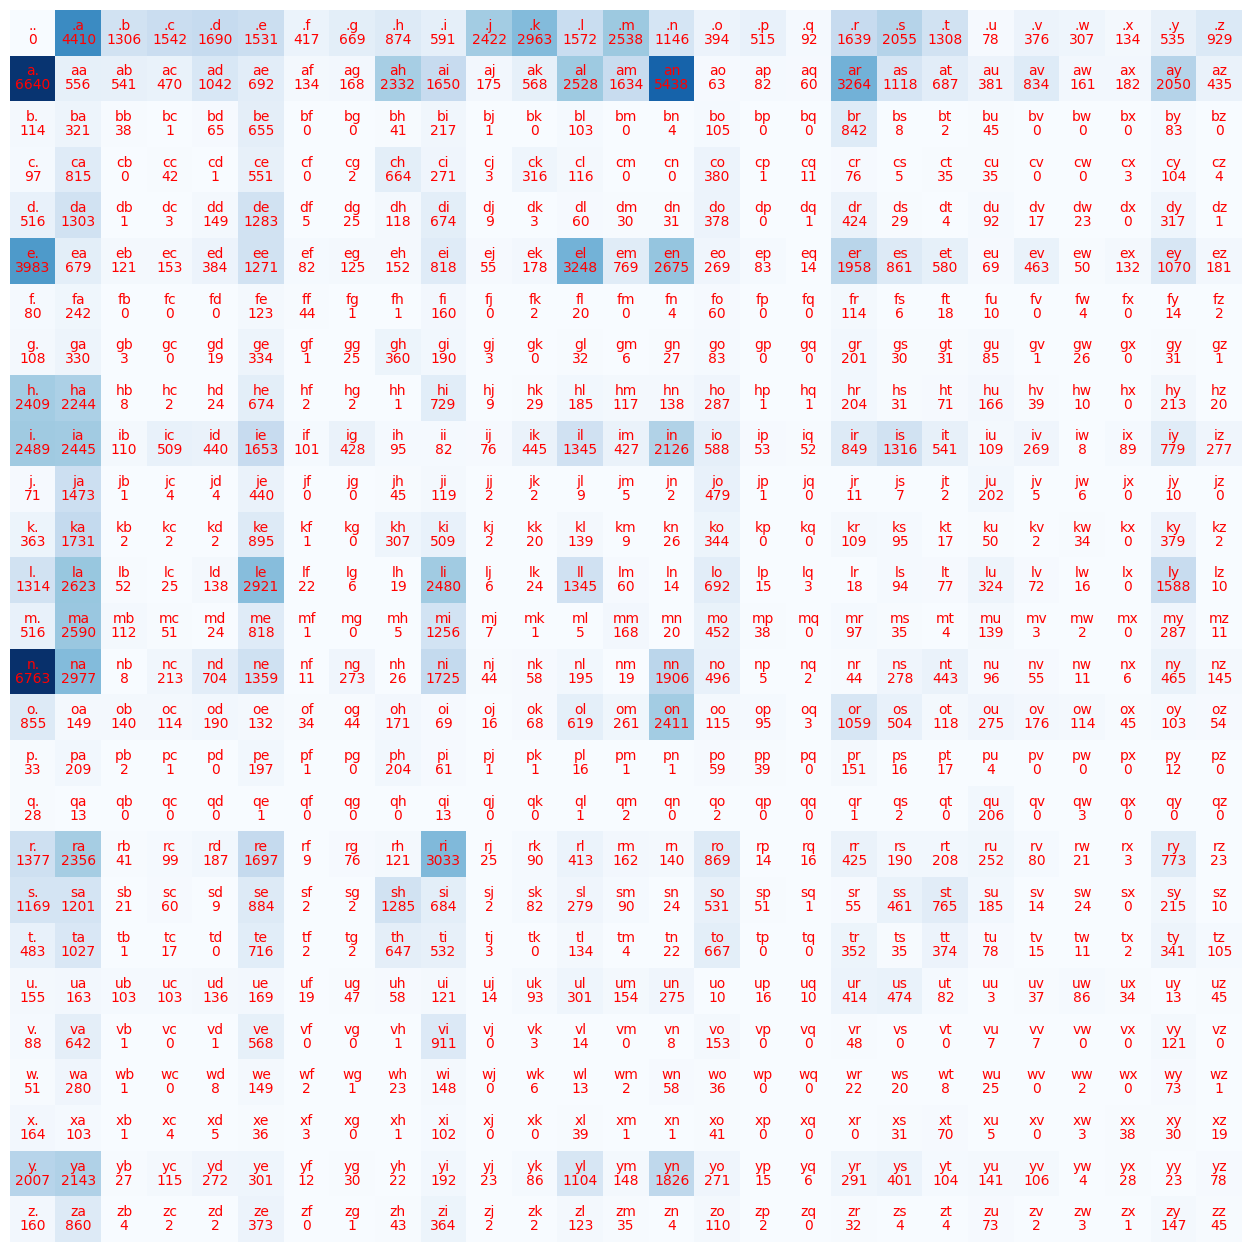

In [23]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap = 'Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i]+itos[j]
        plt.text(j, i, chstr, ha = 'center', va = 'bottom', color = 'red')
        plt.text(j, i, N[i,j].item(), ha = 'center', va = 'top', color = 'red')
plt.axis('off')

左上角第一个表示 `..`这个情况出现的次数为0

由于这里 `.` 的index是0，所以 之前的 出现在最后一列的`n<E>=6763`,现在出现在 n所在行的第一列了，`.n=6763` 

同时用`.`作为index 0，上图可以清晰的看出：
1. 第一行其实是`a,b,...,z`作为首个字符出现的次数
2. 第一列其实是`a,b,...,z`作为最后一个字符出现的次数
3. 中间其他就是和其他字符组合出现的次数，在首和尾之间出现的情况

In [26]:
# N[0]  # 等价于 N[0,:]
p = N[0].float()  # 转为浮点数，准备归一化为概率
p = p/sum(p)
p, p.sum()

(tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
         0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
         0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290]),
 tensor(1.))

为了从p的概率分布中采样，可以使用
+ torch的multinomial函数（就是根据输入，然后用输入的值来作为采样的权重，返回采样的样本的索引），[torch.multinomial](https://docs.pytorch.org/docs/2.12/generated/torch.multinomial.html)
+ 同时，为了保证采样结果的一致性，这里可以通过控制生成器的种子设置来实现这一效果：[Generator](https://docs.pytorch.org/docs/2.12/generated/torch.Generator.html)

In [32]:
g = torch.Generator().manual_seed(2147483647)
# 是一种创建pytorch生成器对象的确定性方法，即：只要用了这段代码，不管是其他机器或者其他环境，结果都是一致可复现的
p = torch.rand(3, generator = g)
p = p/p.sum()
p  # 验证了，确实和老师显示的一致

tensor([0.6064, 0.3033, 0.0903])

In [33]:
# replacement = True,表示有放回采样（即：采样之后会放回去，下次采样依然有概率采到），我们这里设置是True，但是这个值默认是False，即：不放回采样
torch.multinomial(p, num_samples = 20, replacement = True, generator = g)
# 运行后发现，确实和老师的采样结果都一毛一样

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])

这里的 `p=tensor([0.6064, 0.3033, 0.0903])`

即： 
+ index = 0 的这个数有60%的概率会被采到，20次的话， 会出现12次
+ index = 1 的这个数有30%的概率会被采到，20次/6次
+ index = 2 的这个数有10%的概率会被采到，20次/2次

和上面出现的采样结果一致

采样次数越多，采样结果的数字分布就越接近于这里的概率分布

## 手动采样过程

In [42]:
p = N[0].float()  # 转为浮点数，准备归一化为概率
p = p/p.sum()
print(p)
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item() # 出来的是个列表格式
ix, itos[ix]

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])


(10, 'j')

很尴尬， p的概率值一样， 但是采样出来索引不一样。。。老师是13，对应m；我是10，对应j

In [43]:
p = N[10].float()
p = p/p.sum()
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item() # 出来的是个列表格式
ix, itos[ix]

(1, 'a')

## 循环采样

这里可以知道,整体的采样流程其实就是:
1. 从索引0开始, 因为 index = 0 → `.` 是起始标记
2. 然后就开始从对应的 index对应的行 开始采样, 基于采样结果继续 锁定下一个行,继续采样
3. 直到采样到 `.`停止标记, 就停止采样

In [44]:
g = torch.Generator().manual_seed(2147483647)
ix = 0
result = ''
while True:
    p = N[ix].float()
    p = p/p.sum()
    ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item() 
    print(itos[ix])
    result+=itos[ix]
    if ix==0:
        break
print(f'最终的采样结果为: {result}')    

j
u
n
i
d
e
.
最终的采样结果为: junide.


In [45]:
for i in range(10):
    ix = 0
    result = ''
    while True:
        p = N[ix].float()
        p = p/p.sum()
        ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item() 
        result+=itos[ix]
        if ix==0:
            break
    print(f'最终的采样结果为: {result}')  

最终的采样结果为: janasah.
最终的采样结果为: p.
最终的采样结果为: cony.
最终的采样结果为: a.
最终的采样结果为: nn.
最终的采样结果为: kohin.
最终的采样结果为: tolian.
最终的采样结果为: juee.
最终的采样结果为: ksahnaauranilevias.
最终的采样结果为: dedainrwieta.


这里的 `p.`, `a.`

从模型的角度来说, 它并不清楚这个名字是`p`开头的, 因为是以`.`启动的,同时窗口只有2

但是`p`作为最后一个字符出现的概率并不低(出现了33次, `a.`出现了6000多次), 因此会出现这种情况

所以基于Bigram生成的名字看起来会有点像随机生成的感觉,根本看不出来是人名

In [46]:
for i in range(10):
    ix = 0
    result = ''
    while True:
        p = torch.ones(27)/27.0 # 看一下均匀分布的结果,即直接全部随机生成
        ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item() 
        result+=itos[ix]
        if ix==0:
            break
    print(f'最终的采样结果为: {result}')  

最终的采样结果为: snjyievyvaftbzffvmumthyfodtumjrpfytszwjhrjagq.
最终的采样结果为: coreaysezocfkyjjabdywejfmoifmwyfinwagaasnhsvfihofszxhddgosfmptpagicz.
最终的采样结果为: rjpiufmthdt.
最终的采样结果为: rkrrsru.
最终的采样结果为: iyumuyfy.
最终的采样结果为: mjekujcbkhvupwyhvpvhvccragr.
最终的采样结果为: wdkhwfdztta.
最终的采样结果为: mplyisbxlyhuuiqzavmpocbzthqmimvyqwat.
最终的采样结果为: f.
最终的采样结果为: .


>由此至少可以知道:
>
>Bigram的效果, 肯定比随机生成的要好, 这些先验的出现次数/频率, 还是发挥了一些作用的

In [51]:
# 上面代码有点冗余,改掉
P = N.float()
# P = torch.div(N, N.sum(dim = 1, keepdim = True))
P = N/ N.sum(dim = 1, keepdim = True)
# 注意,这里是一行里所有的加起来,所以是列方向的求和

# N.sum(dim = 1, keepdim = True) 从 N的(27,27)变成了(27,1)的形状
# 这里dim=0和dim=1的求和结果一样, 是因为bigram本身是个对称矩阵,
# P[0]  # 验证一下,和上面结果一样

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

[torch.sum](https://docs.pytorch.org/docs/2.12/generated/torch.sum.html)

[torch.div](https://docs.pytorch.org/docs/2.12/generated/torch.div.html#torch.div)

In [52]:
for i in range(10):
    ix = 0
    result = ''
    while True:
        ix = torch.multinomial(P[ix], num_samples = 1, replacement = True, generator = g).item() 
        result+=itos[ix]
        if ix==0:
            break
    print(f'最终的采样结果为: {result}')  

最终的采样结果为: sely.
最终的采样结果为: tavilitikiesaloeverin.
最终的采样结果为: n.
最终的采样结果为: e.
最终的采样结果为: kalbrenelah.
最终的采样结果为: anen.
最终的采样结果为: ch.
最终的采样结果为: k.
最终的采样结果为: jan.
最终的采样结果为: odridrdenanialilpergha.
